In [2]:
import pandas as pd
import seaborn as sns


In [5]:

df = pd.read_csv("DataCoSupplyChainDataset.csv", encoding="latin1")
print("Shape:", df.shape)

display(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape: (180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class



Columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping date

In [6]:
columns_to_drop = [
    "Customer Email",
    "Customer Password",
    "Customer Fname",
    "Customer Lname",
    "Customer Street",
    "Customer Zipcode",
    "Order Zipcode",
    "Product Description",
    "Product Image"
]


In [17]:
df_clean=df.drop(columns=columns_to_drop)

In [18]:
df_clean.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Region,Order State,Order Status,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Southeast Asia,Java Occidental,COMPLETE,1360,73,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,South Asia,Rajastán,PENDING,1360,73,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,South Asia,Rajastán,CLOSED,1360,73,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Oceania,Queensland,COMPLETE,1360,73,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Oceania,Queensland,PENDING_PAYMENT,1360,73,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [10]:
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (180519, 53)
Cleaned shape: (180519, 44)


In [11]:
print("\nRemaining missing values:")
print(df_clean.isnull().sum().sort_values(ascending=False).head(10))


Remaining missing values:
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Customer City                    0
dtype: int64


In [12]:
print("Duplicate rows:", df_clean.duplicated().sum())

print("\nDelivery Status:")
print(df_clean["Delivery Status"].value_counts())

print("\nOrder Status:")
print(df_clean["Order Status"].value_counts())

print("\nShipping Mode:")
print(df_clean["Shipping Mode"].value_counts())

Duplicate rows: 0

Delivery Status:
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

Order Status:
Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64

Shipping Mode:
Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64


In [13]:
print("\nShipping days:")
print(df_clean[
    ["Days for shipping (real)", "Days for shipment (scheduled)"]
].describe())


Shipping days:
       Days for shipping (real)  Days for shipment (scheduled)
count             180519.000000                  180519.000000
mean                   3.497654                       2.931847
std                    1.623722                       1.374449
min                    0.000000                       0.000000
25%                    2.000000                       2.000000
50%                    3.000000                       4.000000
75%                    5.000000                       4.000000
max                    6.000000                       4.000000


In [14]:
df_clean["Delivery Delay"]=(df_clean["Days for shipping (real)"]- df_clean["Days for shipment (scheduled)"])

In [45]:
df_clean.head(10)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,order_month,order_year,order_month_year
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,1360,73,Smart watch,327.75,0,2/3/2018 22:56,Standard Class,1,2018,Jan 2018
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,1360,73,Smart watch,327.75,0,1/18/2018 12:27,Standard Class,1,2018,Jan 2018
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,1360,73,Smart watch,327.75,0,1/17/2018 12:06,Standard Class,1,2018,Jan 2018
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,1360,73,Smart watch,327.75,0,1/16/2018 11:45,Standard Class,1,2018,Jan 2018
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,1360,73,Smart watch,327.75,0,1/15/2018 11:24,Standard Class,1,2018,Jan 2018
5,TRANSFER,6,4,18.580000,294.980011,Shipping canceled,0,73,Sporting Goods,Tonawanda,...,1360,73,Smart watch,327.75,0,1/19/2018 11:03,Standard Class,1,2018,Jan 2018
6,DEBIT,2,1,95.180000,288.420013,Late delivery,1,73,Sporting Goods,Caguas,...,1360,73,Smart watch,327.75,0,1/15/2018 10:42,First Class,1,2018,Jan 2018
7,TRANSFER,2,1,68.430000,285.140015,Late delivery,1,73,Sporting Goods,Miami,...,1360,73,Smart watch,327.75,0,1/15/2018 10:21,First Class,1,2018,Jan 2018
8,CASH,3,2,133.720001,278.589996,Late delivery,1,73,Sporting Goods,Caguas,...,1360,73,Smart watch,327.75,0,1/16/2018 10:00,Second Class,1,2018,Jan 2018
9,CASH,2,1,132.149994,275.309998,Late delivery,1,73,Sporting Goods,San Ramon,...,1360,73,Smart watch,327.75,0,1/15/2018 9:39,First Class,1,2018,Jan 2018


In [16]:
df_clean[
    [
        "Days for shipping (real)",
        "Days for shipment (scheduled)",
        "Delivery Delay",
        "Delivery Status"
    ]
].head(10)

,Days for shipping (real),Days for shipment (scheduled),Delivery Delay,Delivery Status
0,3,4,-1,Advance shipping
1,5,4,1,Late delivery
2,4,4,0,Shipping on time
3,3,4,-1,Advance shipping
4,2,4,-2,Advance shipping
5,6,4,2,Shipping canceled
6,2,1,1,Late delivery
7,2,1,1,Late delivery
8,3,2,1,Late delivery
9,2,1,1,Late delivery


In [28]:
(df_clean["Delivery Status"] == "Late delivery").sum()

np.int64(98977)

In [29]:
(df_clean["Delivery Status"] == "Advance shipping").sum()

np.int64(41592)

In [30]:
(df_clean["Delivery Status"] == "Shipping on time").sum()

np.int64(32196)

In [31]:
(df_clean["Delivery Status"] == "Shipping canceled").sum()

np.int64(7754)

In [32]:
(df_clean["Late_delivery_risk"]== 0).sum()

np.int64(81542)

In [33]:
(df_clean["Late_delivery_risk"]== 1).sum()

np.int64(98977)

In [34]:
df_clean["order date (DateOrders)"] = pd.to_datetime(
    df_clean["order date (DateOrders)"]
)

print("Earliest Order Date:", df_clean["order date (DateOrders)"].min())
print("Latest Order Date:", df_clean["order date (DateOrders)"].max())

Earliest Order Date: 2015-01-01 00:00:00
Latest Order Date: 2018-01-31 23:38:00


In [44]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 47 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180519 non-null  object        
 1   Days for shipping (real)       180519 non-null  int64         
 2   Days for shipment (scheduled)  180519 non-null  int64         
 3   Benefit per order              180519 non-null  float64       
 4   Sales per customer             180519 non-null  float64       
 5   Delivery Status                180519 non-null  object        
 6   Late_delivery_risk             180519 non-null  int64         
 7   Category Id                    180519 non-null  int64         
 8   Category Name                  180519 non-null  object        
 9   Customer City                  180519 non-null  object        
 10  Customer Country               180519 non-null  object        
 11  

In [43]:
df_clean["order_month"]=df_clean["order date (DateOrders)"].dt.month
df_clean["order_year"]=df_clean["order date (DateOrders)"].dt.year
df_clean["order_month_year"] = df_clean["order date (DateOrders)"].dt.strftime("%b %Y")

In [52]:
late_region=(
    df_clean[df_clean["Delivery Status"]=="Late delivery"]
    .groupby("Order Region")
    .size()
    .sort_values(ascending=False)
)
late_region

Order Region
Central America    15518
Western Europe     15140
South America       8111
Oceania             5482
Southeast Asia      5297
Northern Europe     5292
Southern Europe     5129
Caribbean           4415
South Asia          4350
West of USA         4313
Eastern Asia        3955
East of USA         3849
West Asia           3322
US Center           3252
South of  USA       2256
Eastern Europe      2182
West Africa         1953
North Africa        1762
East Africa         1036
Central Africa       972
Southern Africa      617
Canada               468
Central Asia         306
dtype: int64

In [53]:
#Which Shipping Mode has the most late deliveries?

In [55]:
late_ship=(
    df_clean[df_clean["Delivery Status"]=="Late delivery"]
    .groupby("Shipping Mode")
    .size()
    .sort_values(ascending=False)
)
late_ship


Shipping Mode
Standard Class    41023
Second Class      26987
First Class       26513
Same Day           4454
dtype: int64

In [56]:
#

In [57]:
late_cate=(
    df_clean[df_clean["Delivery Status"]=="Late delivery"]
    .groupby("Category Name")
    .size()
    .sort_values(ascending=False)
)
late_cate


Category Name
Cleats                  13496
Men's Footwear          12121
Women's Apparel         11476
Indoor/Outdoor Games    10565
Fishing                  9516
Water Sports             8517
Camping & Hiking         7487
Cardio Equipment         6805
Shop By Sport            6058
Electronics              1770
Accessories              1014
Golf Balls                805
Girls' Apparel            664
Golf Gloves               602
Trade-In                  542
Video Games               455
Women's Clothing          367
Baseball & Softball       349
Children's Clothing       348
Cameras                   344
Hockey                    329
Toys                      291
Golf Shoes                291
Pet Supplies              290
Crafts                    271
Garden                    270
DVDs                      259
Music                     248
Hunting & Shooting        247
Consumer Electronics      238
Boxing & MMA              238
Books                     229
Golf Apparel              

In [58]:
late_cust=(
    df_clean[df_clean["Delivery Status"]=="Late delivery"]
    .groupby("Customer Segment")
    .size()
    .sort_values(ascending=False)
)
late_cust

Customer Segment
Consumer       51248
Corporate      29982
Home Office    17747
dtype: int64

In [59]:
#

In [60]:
late_month = (
    df_clean[df_clean["Delivery Status"] == "Late delivery"]
    .groupby("order_month_year")
    .size()
)

print(late_month)

order_month_year
Apr 2015    2760
Apr 2016    2815
Apr 2017    2803
Aug 2015    2936
Aug 2016    2948
Aug 2017    2994
Dec 2015    2937
Dec 2016    2954
Dec 2017    1172
Feb 2015    2594
Feb 2016    2650
Feb 2017    2682
Jan 2015    2880
Jan 2016    2955
Jan 2017    2797
Jan 2018    1195
Jul 2015    2939
Jul 2016    2755
Jul 2017    2913
Jun 2015    2778
Jun 2016    2873
Jun 2017    2649
Mar 2015    2936
Mar 2016    2905
Mar 2017    2955
May 2015    2951
May 2016    2951
May 2017    2843
Nov 2015    2841
Nov 2016    2846
Nov 2017    1132
Oct 2015    2906
Oct 2016    2957
Oct 2017    1210
Sep 2015    2914
Sep 2016    2837
Sep 2017    2814
dtype: int64


In [61]:
late_month = late_month.reindex(
    pd.to_datetime(late_month.index, format="%b %Y").sort_values().strftime("%b %Y")
)

print(late_month)

order_month_year
Jan 2015    2880
Feb 2015    2594
Mar 2015    2936
Apr 2015    2760
May 2015    2951
Jun 2015    2778
Jul 2015    2939
Aug 2015    2936
Sep 2015    2914
Oct 2015    2906
Nov 2015    2841
Dec 2015    2937
Jan 2016    2955
Feb 2016    2650
Mar 2016    2905
Apr 2016    2815
May 2016    2951
Jun 2016    2873
Jul 2016    2755
Aug 2016    2948
Sep 2016    2837
Oct 2016    2957
Nov 2016    2846
Dec 2016    2954
Jan 2017    2797
Feb 2017    2682
Mar 2017    2955
Apr 2017    2803
May 2017    2843
Jun 2017    2649
Jul 2017    2913
Aug 2017    2994
Sep 2017    2814
Oct 2017    1210
Nov 2017    1132
Dec 2017    1172
Jan 2018    1195
dtype: int64


In [62]:
actual_avg = df_clean["Days for shipping (real)"].mean()
scheduled_avg = df_clean["Days for shipment (scheduled)"].mean()

difference = actual_avg - scheduled_avg

print("Average Actual Shipping Days:", actual_avg)
print("Average Scheduled Shipping Days:", scheduled_avg)
print("Average Difference:", difference)

Average Actual Shipping Days: 3.4976539865609713
Average Scheduled Shipping Days: 2.931846509231715
Average Difference: 0.5658074773292561


In [63]:
#Which shipping mode has the highest risk of late delivery?

In [64]:
shipping_analysis = (
    df_clean.groupby("Shipping Mode")
    .agg(
        Total_Orders=("Delivery Status", "size"),
        Late_Deliveries=("Delivery Status", lambda x: (x == "Late delivery").sum())
    )
)

shipping_analysis["Late_Delivery_Rate"] = (
    shipping_analysis["Late_Deliveries"]
    / shipping_analysis["Total_Orders"]
    * 100
)

shipping_analysis = shipping_analysis.sort_values(
    "Late_Delivery_Rate",
    ascending=False
)

print(shipping_analysis)

                Total_Orders  Late_Deliveries  Late_Delivery_Rate
Shipping Mode                                                    
First Class            27814            26513           95.322499
Second Class           35216            26987           76.632781
Same Day                9737             4454           45.743042
Standard Class        107752            41023           38.071683


In [65]:
region_analysis = (
    df_clean.groupby("Order Region")
    .agg(
        Total_Orders=("Delivery Status", "size"),
        Late_Deliveries=("Delivery Status", lambda x: (x == "Late delivery").sum())
    )
)

region_analysis["Late_Delivery_Rate"] = (
    region_analysis["Late_Deliveries"]
    / region_analysis["Total_Orders"]
    * 100
)

region_analysis = region_analysis.sort_values(
    "Late_Delivery_Rate",
    ascending=False
)

print(region_analysis)

                 Total_Orders  Late_Deliveries  Late_Delivery_Rate
Order Region                                                      
Central Africa           1677              972           57.960644
South Asia               7731             4350           56.266977
East Africa              1852             1036           55.939525
Western Europe          27109            15140           55.848611
South of  USA            4045             2256           55.772559
Eastern Europe           3920             2182           55.663265
East of USA              6915             3849           55.661605
Southeast Asia           9539             5297           55.529930
Central Asia              553              306           55.334539
West Asia                6009             3322           55.283741
US Center                5887             3252           55.240360
Central America         28341            15518           54.754596
North Africa             3232             1762           54.51

In [66]:
segment_analysis = (
    df_clean.groupby("Customer Segment")
    .agg(
        Total_Orders=("Delivery Status", "size"),
        Late_Deliveries=("Delivery Status", lambda x: (x == "Late delivery").sum())
    )
)

segment_analysis["Late_Delivery_Rate"] = (
    segment_analysis["Late_Deliveries"]
    / segment_analysis["Total_Orders"]
    * 100
)

segment_analysis = segment_analysis.sort_values(
    "Late_Delivery_Rate",
    ascending=False
)

print(segment_analysis)

                  Total_Orders  Late_Deliveries  Late_Delivery_Rate
Customer Segment                                                   
Home Office              32226            17747           55.070440
Consumer                 93504            51248           54.808350
Corporate                54789            29982           54.722663


In [67]:
category_analysis = (
    df_clean.groupby("Category Name")
    .agg(
        Total_Orders=("Delivery Status", "size"),
        Late_Deliveries=("Delivery Status", lambda x: (x == "Late delivery").sum())
    )
)

category_analysis["Late_Delivery_Rate"] = (
    category_analysis["Late_Deliveries"]
    / category_analysis["Total_Orders"]
    * 100
)

category_analysis = category_analysis.sort_values(
    "Late_Delivery_Rate",
    ascending=False
)

print(category_analysis)

                      Total_Orders  Late_Deliveries  Late_Delivery_Rate
Category Name                                                          
Golf Bags & Carts               61               42           68.852459
Lacrosse                       343              206           60.058309
Pet Supplies                   492              290           58.943089
Cameras                        592              344           58.108108
Strength Training              111               64           57.657658
As Seen on  TV!                 68               39           57.352941
Music                          434              248           57.142857
Accessories                   1780             1014           56.966292
Fitness Accessories            309              176           56.957929
Books                          405              229           56.543210
Women's Clothing               650              367           56.461538
Boxing & MMA                   423              238           56

In [68]:
delivery_performance = (
    df_clean["Delivery Status"]
    .value_counts()
    .to_frame("Order_Count")
)

delivery_performance["Percentage"] = (
    delivery_performance["Order_Count"]
    / delivery_performance["Order_Count"].sum()
    * 100
)

print(delivery_performance)

                   Order_Count  Percentage
Delivery Status                           
Late delivery            98977   54.829132
Advance shipping         41592   23.040234
Shipping on time         32196   17.835242
Shipping canceled         7754    4.295393


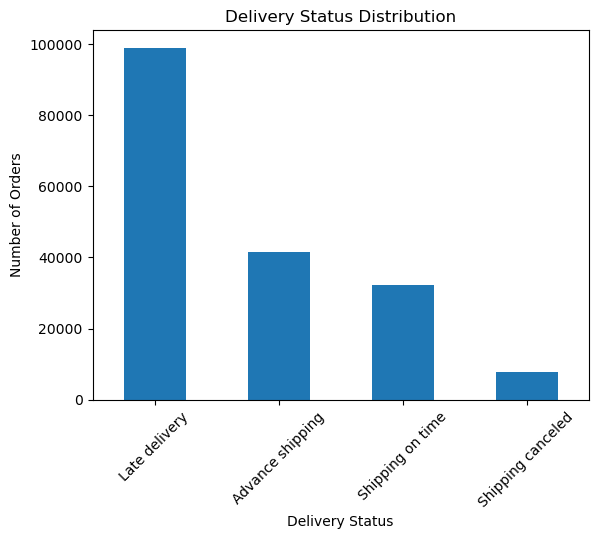

In [70]:
import matplotlib.pyplot as plt

delivery_performance["Order_Count"].plot(kind="bar")

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

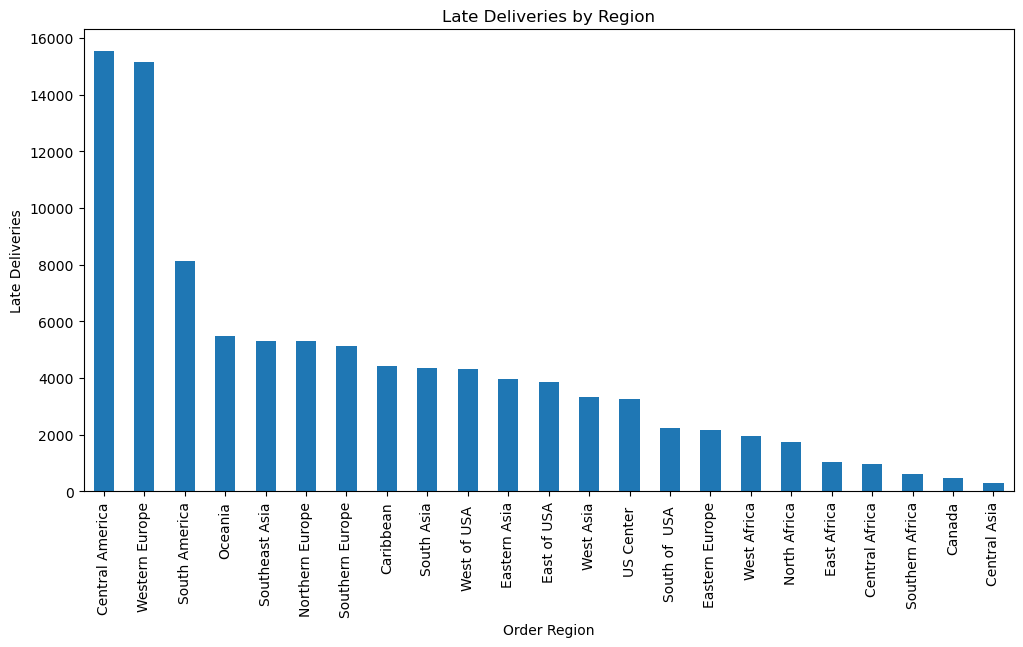

In [71]:
late_region.plot(kind="bar", figsize=(12, 6))

plt.title("Late Deliveries by Region")
plt.xlabel("Order Region")
plt.ylabel("Late Deliveries")
plt.xticks(rotation=90)
plt.show()

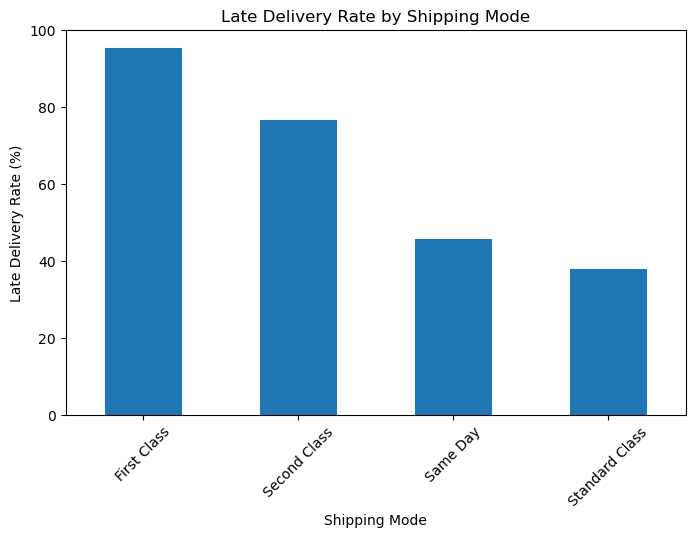

In [72]:
shipping_analysis["Late_Delivery_Rate"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Late Delivery Rate by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=45)
plt.show()

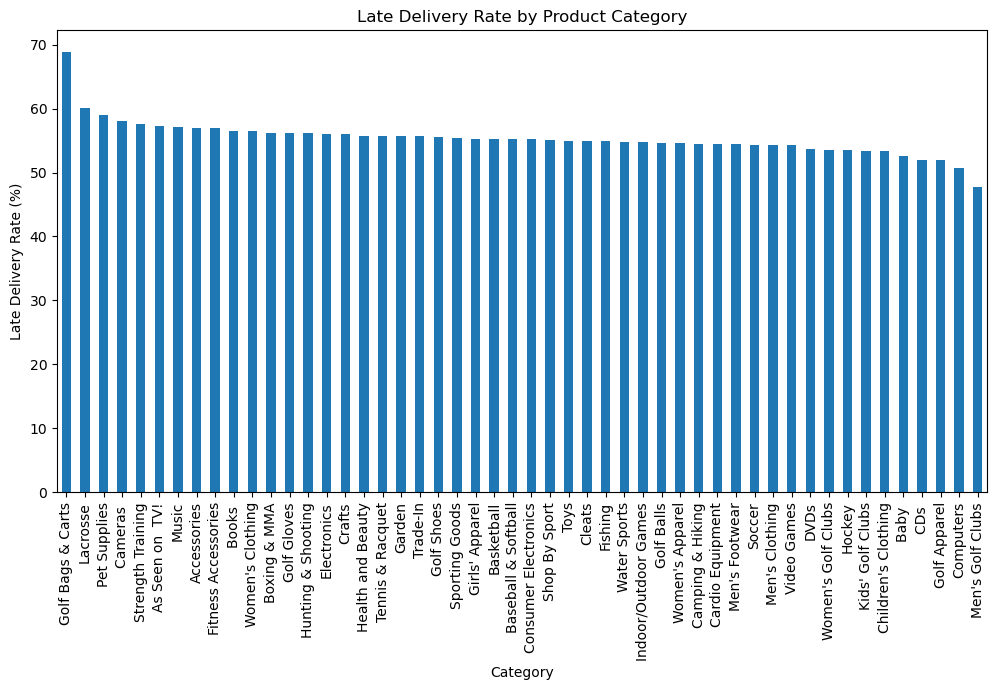

In [73]:
category_analysis["Late_Delivery_Rate"].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Late Delivery Rate by Product Category")
plt.xlabel("Category")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=90)
plt.show()

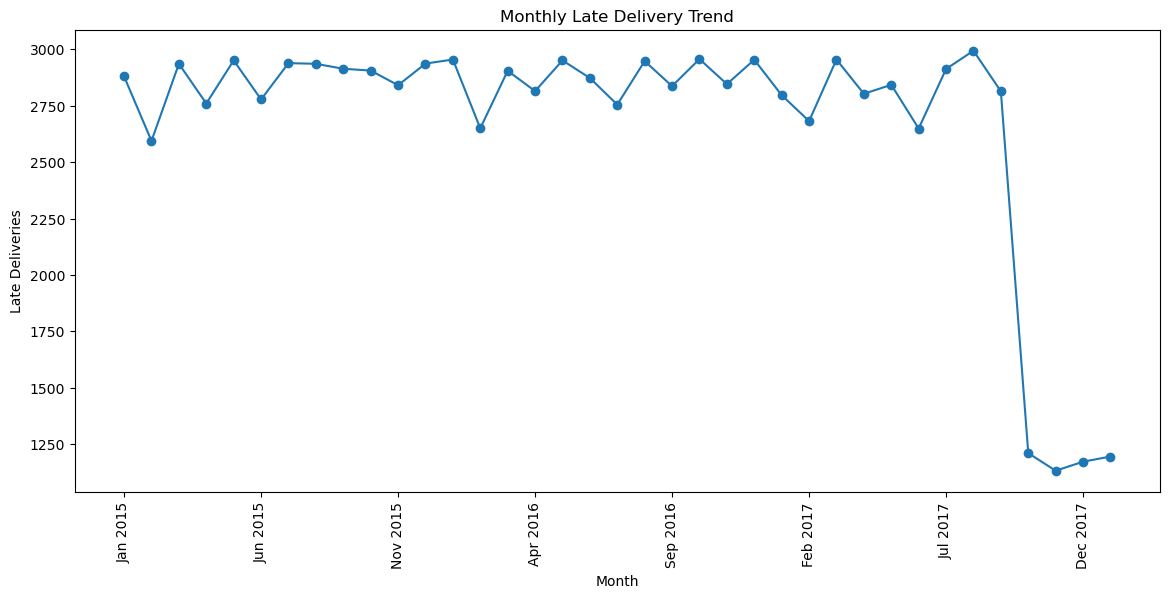

In [74]:
late_month.plot(
    kind="line",
    figsize=(14, 6),
    marker="o"
)

plt.title("Monthly Late Delivery Trend")
plt.xlabel("Month")
plt.ylabel("Late Deliveries")
plt.xticks(rotation=90)
plt.show()

In [75]:
df_clean.to_csv("delivery_data_clean.csv", index=False)

print("Cleaned data exported successfully!")

Cleaned data exported successfully!


In [76]:
import os

print(os.path.exists("delivery_data_clean.csv"))

True
